# Risk Prediction Model

1. Load dataset
2. Add realistic noise (fix perfect-score issue)
3. Check missing values & class balance
4. Exploratory analysis (boxplots)
5. Feature engineering
6. Train/test split 80/20
7. Train: Logistic Regression, Decision Tree, Random Forest, XGBoost
8. Compare results (Accuracy, Precision, Recall, F1-score)
9. Confusion matrix + classification report for best model
10. Feature importance
11. Save trained model


## 0. Imports & Settings

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    from sklearn.ensemble import GradientBoostingClassifier
    HAS_XGB = False
    print("xgboost not installed — using GradientBoostingClassifier instead.")
    print("Run: pip install xgboost")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")
print("All imports OK.")


All imports OK.


## 1. Load Dataset

Update `DATASET_PATH` to point to your file if needed.  
Row 2 is the header (`header=1`) because row 1 contains group labels.


In [ ]:
DATASET_PATH = "software_project_risk_data.xlsx"  

df = pd.read_excel(DATASET_PATH, header=1)
df.columns = df.columns.str.replace("\n", " ", regex=False).str.strip()

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()


Shape: (1500, 28)
Columns: ['Project ID', 'Team Size', 'Developer Experience', 'Team Turnover', 'Project Size', 'KLOC', 'Complexity Score', 'Functional Size', 'Estimated Effort', 'Estimated Duration', 'Schedule Pressure', 'Productivity Rate', 'Sprint Number', 'Days Until Deadline', 'Requirements Changes', 'Total Tasks', 'Completed Tasks', 'Pending Tasks', 'Overdue Tasks', 'Bug Count', 'Resolved Bugs', 'Defect Density', 'Bug Trend', 'Commit Frequency', 'Avg Fix Time (days)', 'Code Changes', 'Velocity Trend', 'RISK LEVEL']


,Project ID,Team Size,Developer Experience,Team Turnover,Project Size,KLOC,Complexity Score,Functional Size,Estimated Effort,Estimated Duration,...,Overdue Tasks,Bug Count,Resolved Bugs,Defect Density,Bug Trend,Commit Frequency,Avg Fix Time (days),Code Changes,Velocity Trend,RISK LEVEL
0,1,12,2,3,1,21.4,4,1069,340.1,69.0,...,44,7,1,0.33,3,4.0,18.5,3798,2,3
1,2,12,2,1,3,63.1,4,647,977.5,12.9,...,44,32,20,0.51,2,8.6,11.5,4045,1,2
2,3,4,3,1,1,54.3,4,1397,816.3,34.7,...,23,31,17,0.57,2,10.9,11.3,3273,2,2
3,4,15,3,1,2,134.1,1,832,227.0,32.8,...,47,13,6,0.10,2,52.8,9.8,3954,2,2
4,5,14,3,0,3,69.4,2,1490,526.1,37.2,...,1,75,54,1.08,2,123.5,3.0,477,2,1


## 2. Add Realistic Noise to Fix Perfect-Score Problem


In [ ]:
NOISE_COLS = [
    "Overdue Tasks", "Completed Tasks", "Pending Tasks",
    "Bug Count", "Resolved Bugs", "Avg Fix Time (days)",
    "Days Until Deadline", "Requirements Changes",
    "Commit Frequency", "Code Changes",
    "Defect Density", "KLOC", "Estimated Effort", "Productivity Rate"
]

df_noisy = df.copy()

for col in NOISE_COLS:
    std = df[col].std()
    noise = np.random.normal(0, std * 1.0, size=len(df))
    df_noisy[col] = df[col] + noise

# Clip count columns to non-negative (can't have -5 bugs)
COUNT_COLS = [
    "Overdue Tasks", "Completed Tasks", "Pending Tasks",
    "Bug Count", "Resolved Bugs", "Requirements Changes"
]
for col in COUNT_COLS:
    df_noisy[col] = df_noisy[col].clip(lower=0)

print("Noise added successfully.")
print(f"Dataset shape: {df_noisy.shape}")

# Verify overlap now exists between classes
print("\nOverdue Tasks range per class (AFTER noise):")
for lvl in [1, 2, 3]:
    s = df_noisy[df_noisy["RISK LEVEL"] == lvl]["Overdue Tasks"]
    print(f"  Risk {lvl}: min={s.min():.1f}  max={s.max():.1f}  mean={s.mean():.1f}")


Noise added successfully.
Dataset shape: (1500, 28)

Overdue Tasks range per class (AFTER noise):
  Risk 1: min=0.0  max=114.1  mean=15.2
  Risk 2: min=0.0  max=120.5  mean=30.9
  Risk 3: min=0.0  max=190.4  mean=59.8


## 3. Check Missing Values & Class Balance

In [21]:
print("Missing values:")
print(df_noisy.isnull().sum())

before = len(df_noisy)
df_noisy.dropna(inplace=True)
print(f"\nRows dropped: {before - len(df_noisy)}")
print(f"Remaining rows: {len(df_noisy)}")

print("\nClass balance:")
print(df_noisy["RISK LEVEL"].value_counts().sort_index()
      .rename({1: "1=Low", 2: "2=Medium", 3: "3=High"}))


Missing values:
Project ID              0
Team Size               0
Developer Experience    0
Team Turnover           0
Project Size            0
KLOC                    0
Complexity Score        0
Functional Size         0
Estimated Effort        0
Estimated Duration      0
Schedule Pressure       0
Productivity Rate       0
Sprint Number           0
Days Until Deadline     0
Requirements Changes    0
Total Tasks             0
Completed Tasks         0
Pending Tasks           0
Overdue Tasks           0
Bug Count               0
Resolved Bugs           0
Defect Density          0
Bug Trend               0
Commit Frequency        0
Avg Fix Time (days)     0
Code Changes            0
Velocity Trend          0
RISK LEVEL              0
dtype: int64

Rows dropped: 0
Remaining rows: 1500

Class balance:
RISK LEVEL
1=Low       550
2=Medium    500
3=High      450
Name: count, dtype: int64


## 4. Exploratory Analysis (Boxplots by Risk Level)

D:\Temp\ipykernel_888\3956023900.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_noisy, x="RISK LEVEL", y=feat, ax=ax, palette="Set2")
D:\Temp\ipykernel_888\3956023900.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_noisy, x="RISK LEVEL", y=feat, ax=ax, palette="Set2")
D:\Temp\ipykernel_888\3956023900.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_noisy, x="RISK LEVEL", y=feat, ax=ax, palette="Set2")


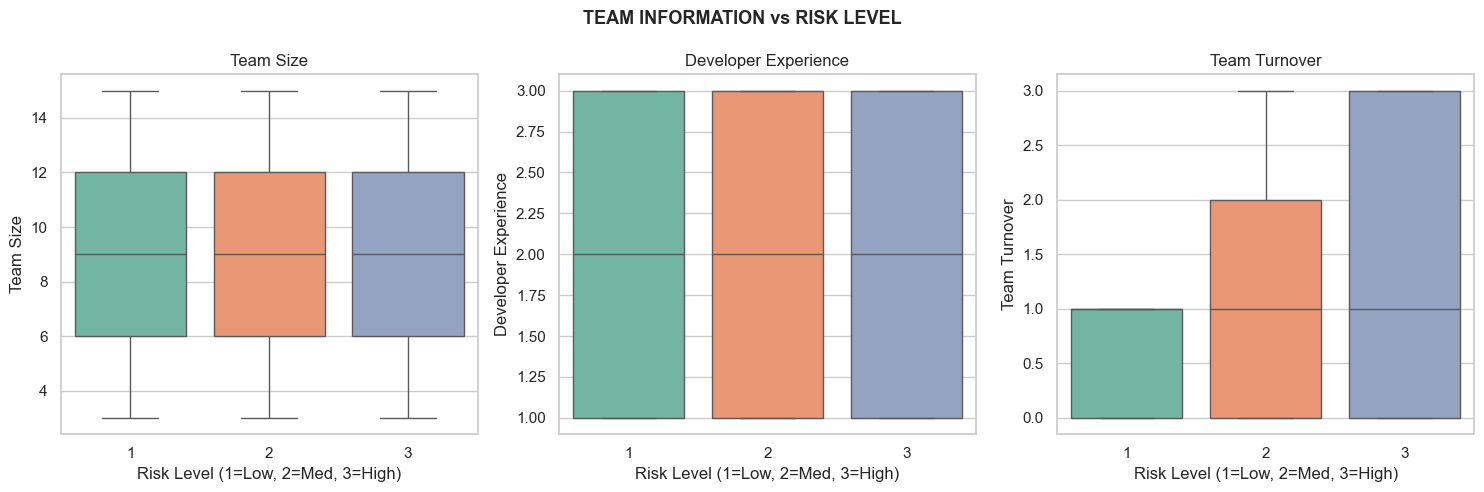

In [22]:
# Team Information
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("TEAM INFORMATION vs RISK LEVEL", fontsize=13, fontweight="bold")
for ax, feat in zip(axes, ["Team Size", "Developer Experience", "Team Turnover"]):
    sns.boxplot(data=df_noisy, x="RISK LEVEL", y=feat, ax=ax, palette="Set2")
    ax.set_title(feat)
    ax.set_xlabel("Risk Level (1=Low, 2=Med, 3=High)")
plt.tight_layout(); plt.show()


D:\Temp\ipykernel_888\4013885679.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_noisy, x="RISK LEVEL", y=feat, ax=ax, palette="Set2")
D:\Temp\ipykernel_888\4013885679.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_noisy, x="RISK LEVEL", y=feat, ax=ax, palette="Set2")
D:\Temp\ipykernel_888\4013885679.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_noisy, x="RISK LEVEL", y=feat, ax=ax, palette="Set2")
D:\Temp\ipykernel_888\4013885679.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is depre

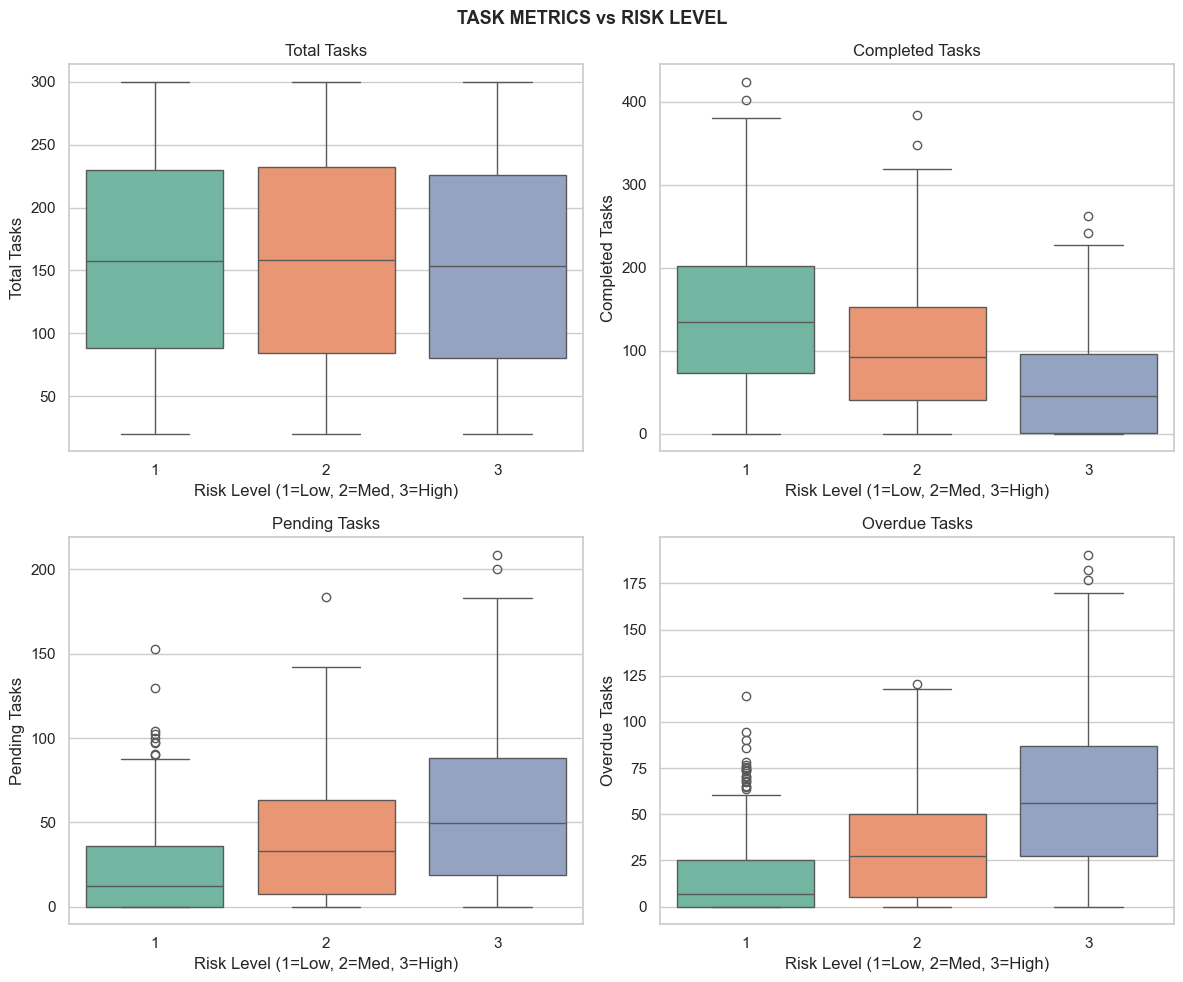

In [23]:
# Task Metrics
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("TASK METRICS vs RISK LEVEL", fontsize=13, fontweight="bold")
for ax, feat in zip(axes.flat, ["Total Tasks", "Completed Tasks", "Pending Tasks", "Overdue Tasks"]):
    sns.boxplot(data=df_noisy, x="RISK LEVEL", y=feat, ax=ax, palette="Set2")
    ax.set_title(feat)
    ax.set_xlabel("Risk Level (1=Low, 2=Med, 3=High)")
plt.tight_layout(); plt.show()


D:\Temp\ipykernel_888\2109266929.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_noisy, x="RISK LEVEL", y=feat, ax=ax, palette="Set2")
D:\Temp\ipykernel_888\2109266929.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_noisy, x="RISK LEVEL", y=feat, ax=ax, palette="Set2")
D:\Temp\ipykernel_888\2109266929.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_noisy, x="RISK LEVEL", y=feat, ax=ax, palette="Set2")
D:\Temp\ipykernel_888\2109266929.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is depre

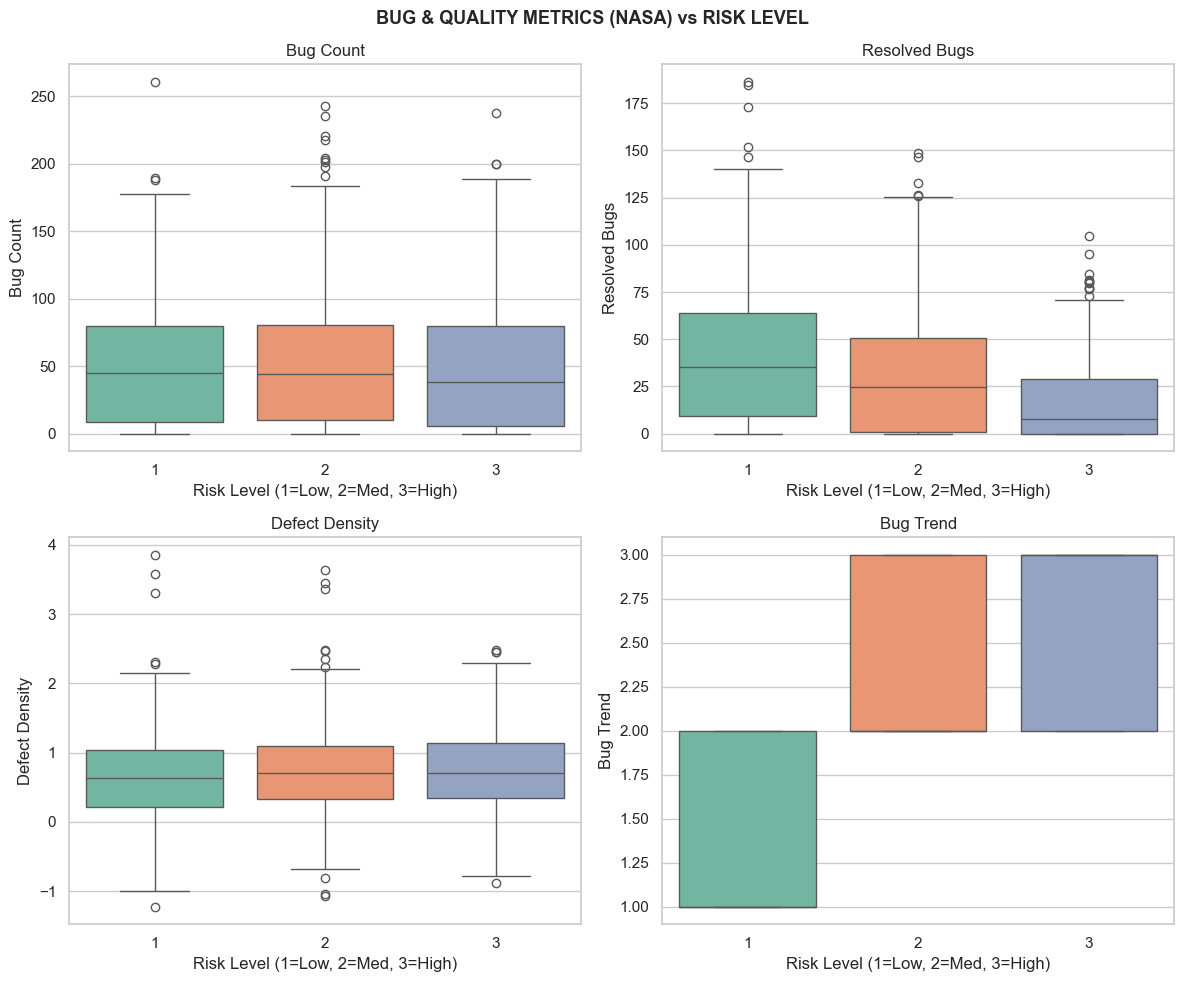

In [24]:
# Bug & Quality
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("BUG & QUALITY METRICS (NASA) vs RISK LEVEL", fontsize=13, fontweight="bold")
for ax, feat in zip(axes.flat, ["Bug Count", "Resolved Bugs", "Defect Density", "Bug Trend"]):
    sns.boxplot(data=df_noisy, x="RISK LEVEL", y=feat, ax=ax, palette="Set2")
    ax.set_title(feat)
    ax.set_xlabel("Risk Level (1=Low, 2=Med, 3=High)")
plt.tight_layout(); plt.show()


D:\Temp\ipykernel_888\3508615271.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_noisy, x="RISK LEVEL", y=feat, ax=ax, palette="Set2")
D:\Temp\ipykernel_888\3508615271.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_noisy, x="RISK LEVEL", y=feat, ax=ax, palette="Set2")
D:\Temp\ipykernel_888\3508615271.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_noisy, x="RISK LEVEL", y=feat, ax=ax, palette="Set2")
D:\Temp\ipykernel_888\3508615271.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is depre

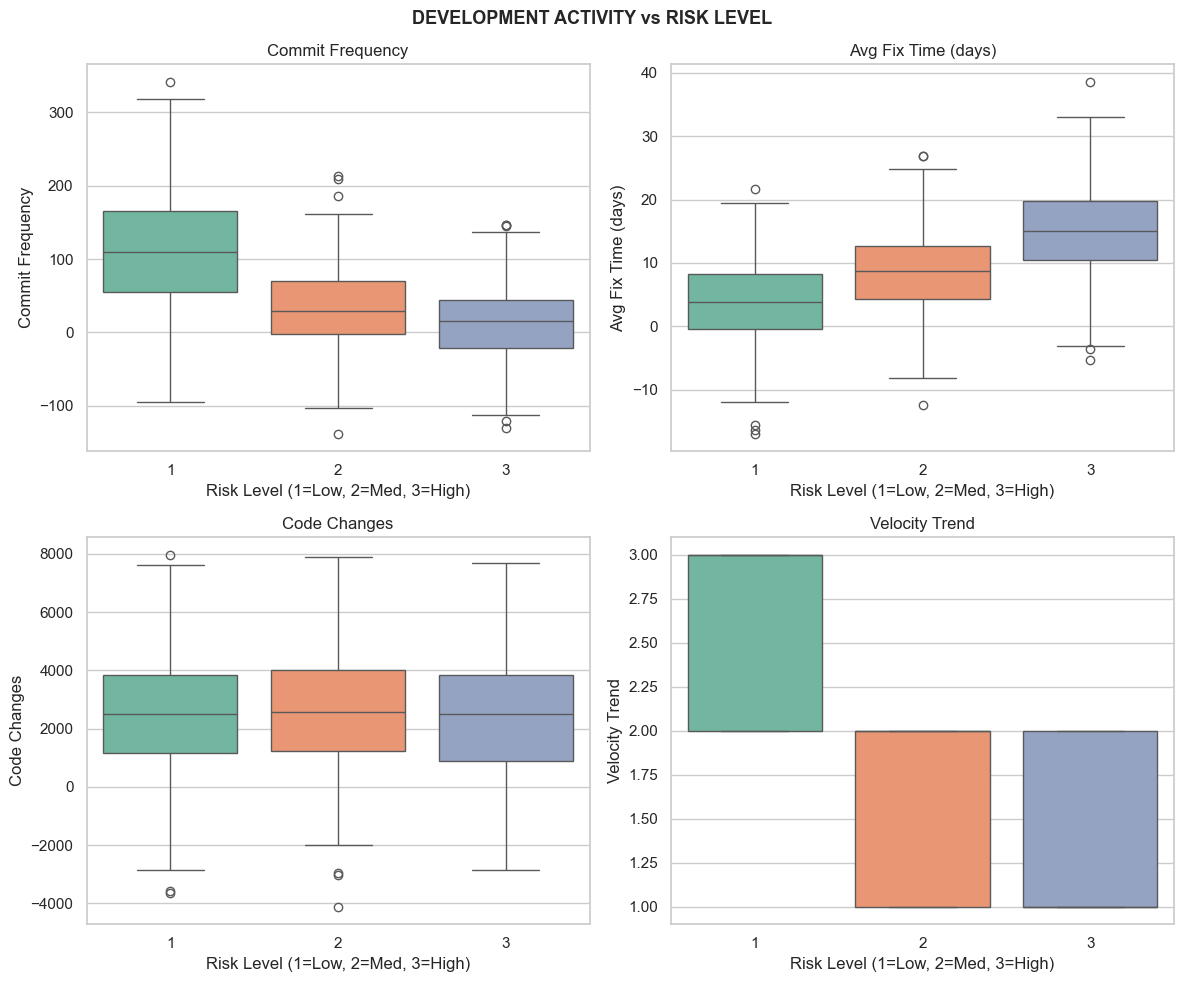

In [25]:
# Development Activity
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("DEVELOPMENT ACTIVITY vs RISK LEVEL", fontsize=13, fontweight="bold")
for ax, feat in zip(axes.flat, ["Commit Frequency", "Avg Fix Time (days)", "Code Changes", "Velocity Trend"]):
    sns.boxplot(data=df_noisy, x="RISK LEVEL", y=feat, ax=ax, palette="Set2")
    ax.set_title(feat)
    ax.set_xlabel("Risk Level (1=Low, 2=Med, 3=High)")
plt.tight_layout(); plt.show()


## 5. Feature Engineering


In [26]:
df_noisy["completion_rate"]     = df_noisy["Completed Tasks"] / df_noisy["Total Tasks"].replace(0, 1)
df_noisy["overdue_ratio"]       = df_noisy["Overdue Tasks"]   / df_noisy["Total Tasks"].replace(0, 1)
df_noisy["bug_resolution_rate"] = df_noisy["Resolved Bugs"]   / df_noisy["Bug Count"].replace(0, 1)
df_noisy["bug_density"]         = df_noisy["Bug Count"]        / df_noisy["Total Tasks"].replace(0, 1)

FEATURE_COLS = [
    "Team Size", "Developer Experience", "Team Turnover",
    "Project Size", "KLOC", "Complexity Score", "Functional Size",
    "Estimated Effort", "Estimated Duration", "Schedule Pressure",
    "Productivity Rate", "Sprint Number", "Days Until Deadline",
    "Requirements Changes", "Total Tasks", "Completed Tasks",
    "Pending Tasks", "Overdue Tasks", "Bug Count", "Resolved Bugs",
    "Defect Density", "Bug Trend", "Commit Frequency",
    "Avg Fix Time (days)", "Code Changes", "Velocity Trend",
    "completion_rate", "overdue_ratio", "bug_resolution_rate", "bug_density"
]

X = df_noisy[FEATURE_COLS]
y_raw = df_noisy["RISK LEVEL"]

# Encode target to integer indices (required by XGBoost)
le = LabelEncoder()
y = le.fit_transform(y_raw)
print("Class mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
print(f"Feature matrix: {X.shape}   Target: {y.shape}")


Class mapping: {np.int64(1): np.int64(0), np.int64(2): np.int64(1), np.int64(3): np.int64(2)}
Feature matrix: (1500, 30)   Target: (1500,)


## 6. Train / Test Split (70 / 30)

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training set : {X_train.shape[0]} rows")
print(f"Test set     : {X_test.shape[0]} rows")
print(f"\nClass distribution in test set:")
unique, counts = np.unique(y_test, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {u} ({le.classes_[u]}): {c} rows")


Training set : 1050 rows
Test set     : 450 rows

Class distribution in test set:
  Class 0 (1): 165 rows
  Class 1 (2): 150 rows
  Class 2 (3): 135 rows


## 7. Train Baseline Models

| Model | Input |
|---|---|
| Logistic Regression | Scaled features |
| Decision Tree | Raw features |
| Random Forest | Raw features |
| XGBoost | Raw features |


In [40]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree":       DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE),
    "Random Forest":       RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)
}

if HAS_XGB:
    models["XGBoost"] = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    random_state=42,
    eval_metric="mlogloss",
    n_jobs=-1
)
else:
    models["GradientBoosting"] = GradientBoostingClassifier(random_state=RANDOM_STATE)

results        = []
trained_models = {}
all_preds      = {}

for name, model in models.items():
    print(f"  Training {name}...", end=" ")
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    trained_models[name] = model
    all_preds[name]      = preds

    results.append({
        "Model":     name,
        "Accuracy":  round(accuracy_score(y_test, preds), 4),
        "Precision": round(precision_score(y_test, preds, average="weighted", zero_division=0), 4),
        "Recall":    round(recall_score(y_test, preds, average="weighted", zero_division=0), 4),
        "F1-score":  round(f1_score(y_test, preds, average="weighted", zero_division=0), 4),
    })
    print("done.")

results_df = (pd.DataFrame(results)
              .sort_values("F1-score", ascending=False)
              .reset_index(drop=True))

print("\n" + "="*55)
print(results_df.to_string(index=False))
print("="*55)


  Training Logistic Regression... done.
  Training Decision Tree... done.
  Training Random Forest... done.
  Training XGBoost... done.

              Model  Accuracy  Precision  Recall  F1-score
            XGBoost    0.8800     0.8829  0.8800    0.8810
Logistic Regression    0.8778     0.8774  0.8778    0.8775
      Random Forest    0.8756     0.8819  0.8756    0.8769
      Decision Tree    0.8467     0.8527  0.8467    0.8481


## 8. Model Comparison Chart

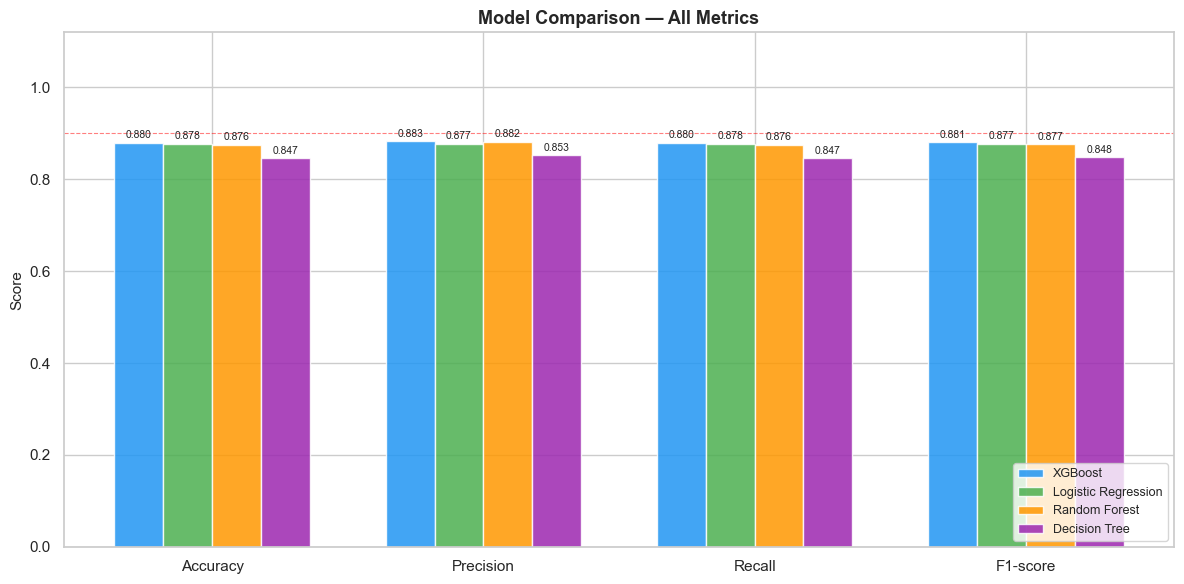


Best model: XGBoost  (F1 = 0.8810)


In [41]:
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
x      = np.arange(len(metrics))
width  = 0.18
colors = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0"]

fig, ax = plt.subplots(figsize=(12, 6))
for i, (_, row) in enumerate(results_df.iterrows()):
    vals = [row[m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=row["Model"],
                  color=colors[i % len(colors)], alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=7.5)

ax.set_xticks(x + width * (len(results_df) - 1) / 2)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Model Comparison — All Metrics", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.axhline(0.9, color="red", linestyle="--", linewidth=0.8, alpha=0.5, label="0.90 threshold")
plt.tight_layout()
plt.show()

print(f"\nBest model: {results_df.iloc[0]['Model']}  (F1 = {results_df.iloc[0]['F1-score']:.4f})")


## 9. Best Model (Classification Report & Confusion Matrix)

Best model : XGBoost
              precision    recall  f1-score   support

           1       0.97      0.93      0.95       165
           2       0.80      0.85      0.83       150
           3       0.87      0.84      0.86       135

    accuracy                           0.88       450
   macro avg       0.88      0.88      0.88       450
weighted avg       0.88      0.88      0.88       450



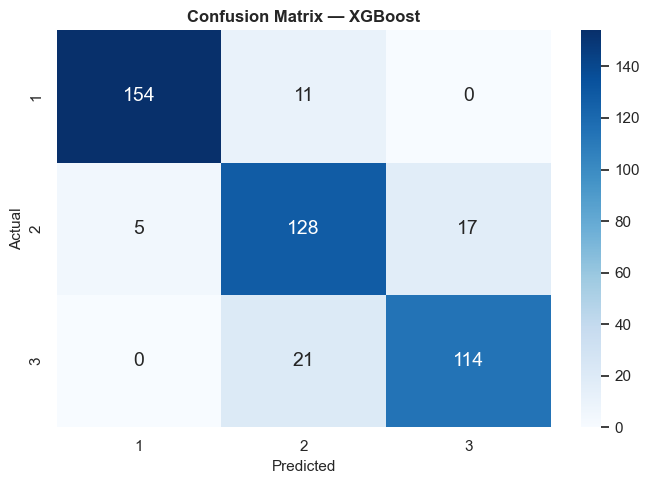

In [42]:
best_name  = results_df.iloc[0]["Model"]
best_model = trained_models[best_name]
best_preds = all_preds[best_name]

print(f"Best model : {best_name}")
print("="*55)
print(classification_report(
    y_test,
    best_preds,
    target_names=[str(x) for x in le.classes_]
))

cm = confusion_matrix(y_test, best_preds)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax,
            annot_kws={"size": 14})
ax.set_xlabel("Predicted", fontsize=11)
ax.set_ylabel("Actual", fontsize=11)
ax.set_title(f"Confusion Matrix — {best_name}", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


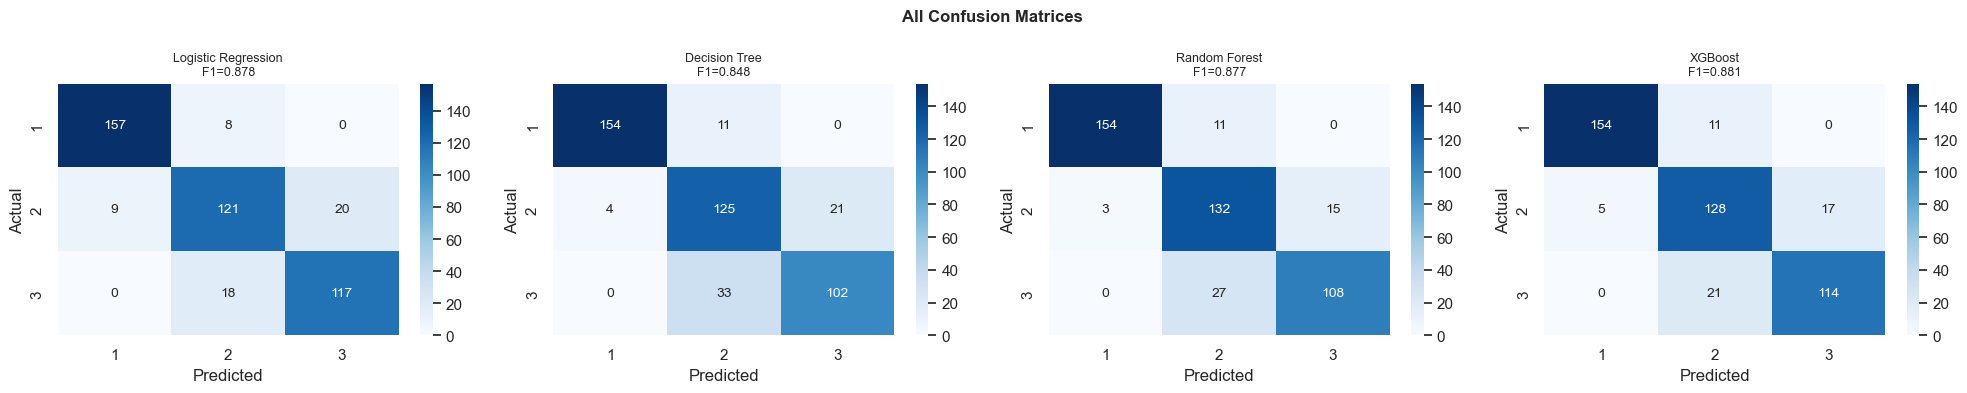

In [44]:
# All confusion matrices side by side
n = len(trained_models)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
if n == 1: axes = [axes]

for ax, (name, preds) in zip(axes, all_preds.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=le.classes_, yticklabels=le.classes_, ax=ax,
                annot_kws={"size":10})
    f1 = f1_score(y_test, preds, average="weighted")
    ax.set_title(f"{name}\nF1={f1:.3f}", fontsize=9)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

fig.suptitle("All Confusion Matrices", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


## 10. Feature Importance


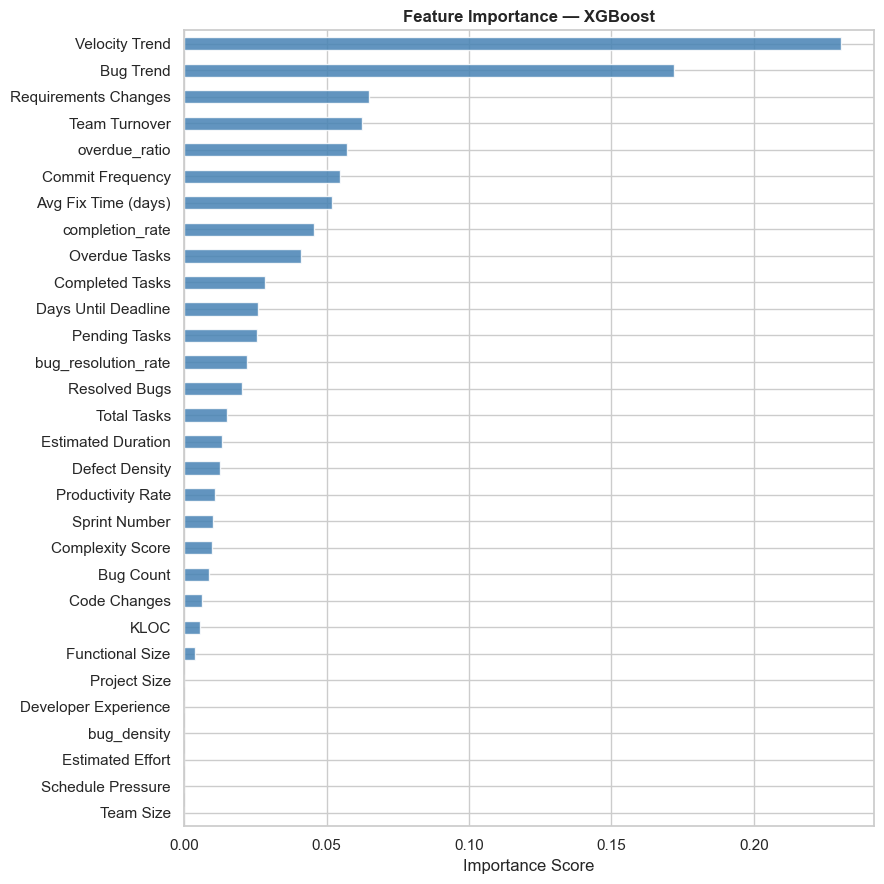

Top 10 most important features:
  Velocity Trend                 0.2306
  Bug Trend                      0.1721
  Requirements Changes           0.0649
  Team Turnover                  0.0625
  overdue_ratio                  0.0572
  Commit Frequency               0.0547
  Avg Fix Time (days)            0.0519
  completion_rate                0.0455
  Overdue Tasks                  0.0412
  Completed Tasks                0.0285


In [45]:
tree_based = ("Decision Tree", "Random Forest", "XGBoost", "GradientBoosting")

if best_name in tree_based:
    importances = pd.Series(best_model.feature_importances_, index=FEATURE_COLS)
    importances = importances.sort_values(ascending=True)

    plt.figure(figsize=(9, 9))
    importances.plot(kind="barh", color="steelblue", alpha=0.85)
    plt.title(f"Feature Importance — {best_name}", fontsize=12, fontweight="bold")
    plt.xlabel("Importance Score")
    plt.tight_layout()
    plt.show()

    print("Top 10 most important features:")
    top10 = importances.sort_values(ascending=False).head(10)
    for feat, imp in top10.items():
        print(f"  {feat:<30} {imp:.4f}")
else:
    # Logistic Regression: magnitude of coefficients
    coef_abs = np.abs(best_model.coef_).mean(axis=0)
    imp_lr = pd.Series(coef_abs, index=FEATURE_COLS).sort_values(ascending=True)
    plt.figure(figsize=(9, 9))
    imp_lr.plot(kind="barh", color="steelblue", alpha=0.85)
    plt.title(f"Feature Importance (|coef| mean) — {best_name}", fontsize=12, fontweight="bold")
    plt.xlabel("Mean |Coefficient|")
    plt.tight_layout()
    plt.show()
    print("Top 10:", imp_lr.sort_values(ascending=False).head(10).round(4).to_string())


## 11. Save Trained Model


In [47]:
import joblib

joblib.dump(best_model, "risk_model.pkl")
joblib.dump(scaler,     "scaler.pkl")
joblib.dump(le,         "label_encoder.pkl")

print("Saved:")
print("  risk_model.pkl     — best trained model")
print("  scaler.pkl         — StandardScaler (needed for Logistic Regression input)")
print("  label_encoder.pkl  — maps 0/1/2 <-> High/Low/Medium")
print(f"\nModel type  : {type(best_model).__name__}")
print(f"Features    : {len(FEATURE_COLS)}")
print(f"Classes     : {list(le.classes_)}")
print(f"Best F1     : {results_df.iloc[0]['F1-score']:.4f}")


Saved:
  risk_model.pkl     — best trained model
  scaler.pkl         — StandardScaler (needed for Logistic Regression input)
  label_encoder.pkl  — maps 0/1/2 <-> High/Low/Medium

Model type  : XGBClassifier
Features    : 30
Classes     : [np.int64(1), np.int64(2), np.int64(3)]
Best F1     : 0.8810
